# 04 — Model training and evaluation

**Owner 3. This uses Module 3 and Module 4.**

The job is multiclass classification: given the conditions around a collision, predict **Fatal / Serious / Slight**.

The dataset only contains collisions. We cannot predict how likely a crash is. We predict how severe it would be, then the app turns those probabilities into a relative safety score.

All reusable code is in `ml/src/train.py`. This notebook is the evidence: dummy baseline first, then Logistic Regression fully evaluated, then two comparison models, then a written choice.

The production artifact is the **whole sklearn Pipeline** (scaler + one-hot encoder + model) saved as `model.joblib`. That is what stops training/serving skew.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, train

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

## 1. Load the feature table

Owner 2 delivers `collisions_features.parquet`. If this clone does not have it (the file is gitignored), `prepare_feature_table()` rebuilds it with **the same** `clean()` and `build_features()` functions already owned by Owners 1 and 2.

The model columns are the lists in `features.get_feature_columns()`:

- **Categorical** — one-hot encoded, because the STATS19 codes are labels, not quantities.
- **Numeric** — standardised, because Logistic Regression is sensitive to scale.

`grid_risk` is **not** a model feature. A cell's severity index includes the collision being predicted, which would leak the target.

`junction_detail` is left out (`train.SERVING_UNAVAILABLE`). A collision record says whether it happened at a junction, but the backend scores whole road sections, which always pass junctions, so it cannot supply that value. Training on a column the live app never has would break every prediction.

In [2]:
df = train.prepare_feature_table()
X, y, feature_columns, cat_cols, num_cols = train.xy_from_features(df)

print("Rows:", f"{len(X):,}")
print("Categorical:", cat_cols)
print("Numeric:", num_cols)
print()
print(y.value_counts().sort_index().rename(config.SEVERITY_LABELS))
print()
print((y.value_counts(normalize=True).sort_index() * 100).round(2).rename(config.SEVERITY_LABELS))

Rows: 513,698
Categorical: ['time_of_day', 'is_weekend', 'road_type', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'adverse_conditions', 'speed_x_roadtype', 'first_road_class']
Numeric: ['hour', 'month', 'day_of_year', 'speed_limit']

collision_severity
Fatal        7550
Serious    116787
Slight     389361
Name: count, dtype: int64

collision_severity
Fatal       1.47
Serious    22.73
Slight     75.80
Name: proportion, dtype: float64


## 2. Stratified split

`stratify=y` keeps the Fatal / Serious / Slight mix the same in train and test. Without it, the test set could easily contain almost no Fatal rows, and recall on Fatal would be meaningless.

In [3]:
X_train, X_test, y_train, y_test = train.split_xy(X, y)
preprocessor = train.make_preprocessor(cat_cols, num_cols)

print("Train:", len(X_train), " Test:", len(X_test))
print("Train mix:\n", y_train.value_counts(normalize=True).sort_index().round(4).rename(config.SEVERITY_LABELS))
print("Test mix:\n", y_test.value_counts(normalize=True).sort_index().round(4).rename(config.SEVERITY_LABELS))

Train: 410958  Test: 102740
Train mix:
 collision_severity
Fatal      0.0147
Serious    0.2273
Slight     0.7580
Name: proportion, dtype: float64
Test mix:
 collision_severity
Fatal      0.0147
Serious    0.2273
Slight     0.7580
Name: proportion, dtype: float64


## 3. Dummy baseline — run this first

`DummyClassifier(strategy="most_frequent")` always predicts Slight.

Accuracy will look high because about 76% of collisions really are Slight. Macro F1 will be poor and **Fatal recall will be zero**. That is the Module 4 point: accuracy is the wrong metric on imbalanced data.

Screenshot this cell.

In [4]:
dummy = train.dummy_model()
dummy.fit(X_train, y_train)
dummy_result = train.evaluate(dummy, X_train, y_train, X_test, y_test, "dummy")


=== dummy ===
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00      1510
     Serious       0.00      0.00      0.00     23357
      Slight       0.76      1.00      0.86     77873

    accuracy                           0.76    102740
   macro avg       0.25      0.33      0.29    102740
weighted avg       0.57      0.76      0.65    102740

accuracy=0.7580  macro_f1=0.2874  train_macro_f1=0.2874  test_macro_f1=0.2874


## 4. Logistic Regression — main model

`class_weight="balanced"` re-weights the loss so Fatal and Serious rows count as much, in total, as the Slight majority. Without it the model would mostly learn to say Slight.

Three classes are handled with a **multinomial** (softmax) Logistic Regression: one coefficient vector per class, probabilities that sum to 1.

`C` is the inverse regularisation strength. Smaller `C` = stronger penalty = simpler model. We sweep `C` on a stratified sample, then run 5-fold stratified CV on the full training set with the chosen value.

In [5]:
logreg, best_C, sweep = train.tune_logreg(preprocessor, X_train, y_train)
print("Best C:", best_C)
pd.DataFrame(sweep)

C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


LogReg C sweep (macro F1 on sample):
  C=0.1   mean macro F1=0.3128
  C=1.0   mean macro F1=0.3128
  C=10.0  mean macro F1=0.3128
Chosen C=0.1
Best C: 0.1


,Cs,mean_macro_f1,best_C
0,0.1,0.312835,0.1
1,1.0,0.312793,0.1
2,10.0,0.312817,0.1


In [6]:
print("5-fold stratified CV on the training set")
cv = train.cross_validate(logreg, X_train, y_train)
print(f"mean macro F1 = {cv['mean']:.4f}  std = {cv['std']:.4f}")

5-fold stratified CV on the training set


C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


  fold 1: macro F1=0.3193


C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


  fold 2: macro F1=0.3166


...

  fold 3: macro F1=0.3166


C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


  fold 4: macro F1=0.3170


C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


  fold 5: macro F1=0.3187
mean macro F1 = 0.3176  std = 0.0011


In [7]:
logreg.fit(X_train, y_train)
logreg_result = train.evaluate(logreg, X_train, y_train, X_test, y_test, "logistic_regression")

print()
print("Overfitting check: train macro F1 vs test macro F1")
print("train:", round(logreg_result["train_macro_f1"], 4))
print("test: ", round(logreg_result["test_macro_f1"], 4))
print("CV mean:", round(cv["mean"], 4))

C:\Users\PCWORLD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(



=== logistic_regression ===
              precision    recall  f1-score   support

       Fatal       0.04      0.66      0.07      1510
     Serious       0.25      0.23      0.24     23357
      Slight       0.80      0.55      0.65     77873

    accuracy                           0.48    102740
   macro avg       0.36      0.48      0.32    102740
weighted avg       0.67      0.48      0.55    102740

accuracy=0.4764  macro_f1=0.3190  train_macro_f1=0.3176  test_macro_f1=0.3190

Overfitting check: train macro F1 vs test macro F1
train: 0.3176
test:  0.319
CV mean: 0.3176


If train and test macro F1 are close, the model is not memorising the training rows. Cross-validation being in the same range is the second check.

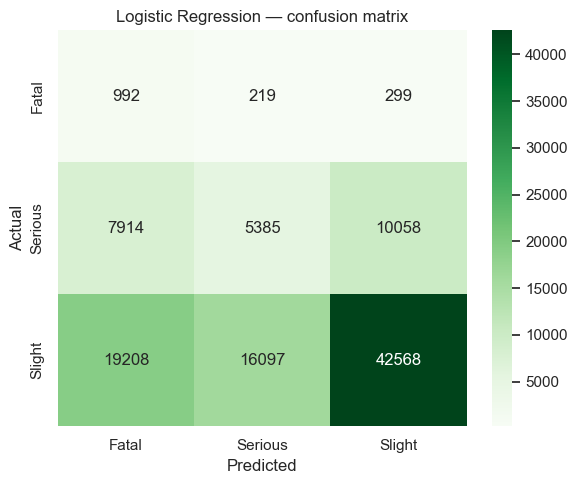

In [8]:
matrix = np.array(logreg_result["confusion_matrix"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=train.CLASS_NAMES,
    yticklabels=train.CLASS_NAMES,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Logistic Regression — confusion matrix")
fig.tight_layout()
fig.savefig(config.ARTIFACTS_DIR / "confusion_matrix.png", dpi=140)
plt.show()

## 5. Coefficient analysis

These weights are what Owner 2 turns into the "why is this risky" text. A positive KSI weight means that feature pushed the prediction towards Fatal or Serious relative to Slight.

In [9]:
coeffs = train.coefficient_table(logreg)
coeff_df = pd.DataFrame(coeffs)
print("Conditions that raise predicted severity")
display(coeff_df.head(15))
print()
print("Conditions that lower predicted severity")
display(coeff_df.tail(10))

Conditions that raise predicted severity


,feature,coef_fatal,coef_serious,coef_slight,ksi_weight
0,cat__road_type_6,0.396748,-0.023721,-0.373026,1.119079
1,cat__weather_conditions_4,0.352692,-0.024643,-0.328049,0.984146
2,num__speed_limit,0.326523,-0.111882,-0.214641,0.643924
3,cat__road_surface_conditions_2,0.241683,-0.039498,-0.202185,0.606555
4,cat__road_type_3,0.249561,-0.053791,-0.195770,0.587310
5,cat__road_surface_conditions_1,0.206421,-0.028295,-0.178126,0.534377
6,cat__time_of_day_early_morning,0.251472,-0.085882,-0.165590,0.496771
7,cat__time_of_day_night,0.177989,-0.021576,-0.156413,0.469238
8,cat__light_conditions_5,0.149628,-0.005321,-0.144307,0.432921
9,cat__weather_conditions_1,0.153312,-0.022424,-0.130888,0.392664



Conditions that lower predicted severity


,feature,coef_fatal,coef_serious,coef_slight,ksi_weight
39,cat__time_of_day_evening_rush,-0.262295,0.096942,0.165353,-0.496060
40,cat__urban_or_rural_area_1,-0.217061,0.049219,0.167842,-0.503526
41,cat__light_conditions_1,-0.249682,0.077840,0.171842,-0.515527
42,cat__weather_conditions_8,-0.271615,0.071532,0.200083,-0.600249
43,cat__road_type_1,-0.335638,0.123091,0.212547,-0.637641
44,cat__time_of_day_morning_rush,-0.253359,0.029559,0.223799,-0.671398
45,cat__first_road_class_1,-0.216285,-0.018551,0.234836,-0.704507
46,cat__weather_conditions_99,-0.284588,-0.007795,0.292383,-0.877149
47,cat__road_type_99,-0.378075,-0.057674,0.435750,-1.307249
48,cat__road_surface_conditions_99,-0.491514,0.020021,0.471493,-1.414479


## 6. Comparison models

Random Forest and XGBoost are **beyond the module**. They are here to ask one question: does a non-linear model help enough to justify losing readable coefficients?

They are not the served model.

In [10]:
forest = train.forest_pipeline(preprocessor)
forest.fit(X_train, y_train)
forest_result = train.evaluate(forest, X_train, y_train, X_test, y_test, "random_forest")


=== random_forest ===
              precision    recall  f1-score   support

       Fatal       0.04      0.54      0.07      1510
     Serious       0.26      0.23      0.25     23357
      Slight       0.80      0.63      0.71     77873

    accuracy                           0.54    102740
   macro avg       0.37      0.47      0.34    102740
weighted avg       0.67      0.54      0.59    102740

accuracy=0.5404  macro_f1=0.3424  train_macro_f1=0.3644  test_macro_f1=0.3424


In [11]:
xgb = train.xgb_pipeline(preprocessor)
train.fit_xgboost(xgb, X_train, y_train)
xgb_result = train.evaluate(xgb, X_train, y_train, X_test, y_test, "xgboost")


=== xgboost ===
              precision    recall  f1-score   support

       Fatal       0.04      0.63      0.07      1510
     Serious       0.25      0.24      0.25     23357
      Slight       0.81      0.56      0.66     77873

    accuracy                           0.49    102740
   macro avg       0.37      0.48      0.33    102740
weighted avg       0.67      0.49      0.56    102740

accuracy=0.4919  macro_f1=0.3269  train_macro_f1=0.3341  test_macro_f1=0.3269


## 7. Compare and choose

We do not pick the highest accuracy. We look at macro F1, Fatal/Serious recall, whether we can explain the prediction, and whether the output is a usable probability.

In [12]:
comparison = pd.DataFrame([
    train.comparison_row("dummy", dummy_result),
    train.comparison_row("logistic_regression", logreg_result),
    train.comparison_row("random_forest", forest_result),
    train.comparison_row("xgboost", xgb_result),
])
display(comparison.round(4))

,model,accuracy,macro_precision,macro_recall,macro_f1
0,dummy,0.7580,0.2527,0.3333,0.2874
1,logistic_regression,0.4764,0.3626,0.4780,0.3190
2,random_forest,0.5404,0.3677,0.4670,0.3424
3,xgboost,0.4919,0.3652,0.4795,0.3269


**Choice: Logistic Regression (`logreg-v1`).**

The dummy baseline proves accuracy is misleading. Logistic Regression, with `class_weight="balanced"`, is the first model that actually looks at Fatal and Serious cases.

Tree models may score a little higher on macro F1. We still serve Logistic Regression because:

1. Its coefficients become the in-app explanations. A safety tool that cannot say *why* a stretch is risky will not be trusted.
2. `predict_proba` is well-behaved and is what the scoring formula uses.
3. The module taught this model. The comparison models are a check, not a replacement.

That is the production decision. The backend loads this pipeline once at startup.

## 8. Save the whole pipeline

`model.joblib` contains the preprocessor **and** the model. `metrics.json` contains the feature column list the backend checks on startup.

In [13]:
(config.ARTIFACTS_DIR / "coefficients.json").write_text(
    __import__("json").dumps(coeffs[:40], indent=2)
)

metrics = {
    "chosen_model": train.CHOSEN_MODEL,
    "selection_reason": (
        "Random Forest and XGBoost are included as a check, not as the served "
        "model. Logistic Regression is the production choice because its "
        "coefficients can be turned into readable reasons for each segment, "
        "class_weight='balanced' lifts recall on Fatal/Serious, and the "
        "backend already scores from those coefficients."
    ),
    "feature_columns": feature_columns,
    "class_labels": train.CLASS_NAMES,
    "best_C": best_C,
    "C_sweep": sweep,
    "cv_macro_f1_mean": cv["mean"],
    "cv_macro_f1_std": cv["std"],
    "cv_folds": cv["folds"],
    "train_macro_f1": logreg_result["train_macro_f1"],
    "test_macro_f1": logreg_result["test_macro_f1"],
    "accuracy": logreg_result["accuracy"],
    "macro_precision": logreg_result["macro_precision"],
    "macro_recall": logreg_result["macro_recall"],
    "macro_f1": logreg_result["macro_f1"],
    "per_class": logreg_result["per_class"],
    "confusion_matrix": logreg_result["confusion_matrix"],
    "comparison": comparison.to_dict(orient="records"),
    "top_ksi_coefficients": coeffs[:15],
}

print("Saved", train.save_metrics(metrics))
print("Saved", train.save_pipeline(logreg))
print("Owner 1 can now load model.joblib. /api/health should show model_loaded: true.")

Saved D:\ML_Final\review-nethushi\ml\artifacts\metrics.json
Saved D:\ML_Final\review-nethushi\ml\artifacts\model.joblib
Owner 1 can now load model.joblib. /api/health should show model_loaded: true.
